# SI Demo — Descriptive Analytics *(Build 2)*
**Domain:** Amman Rides (fictional ride-sharing service)  
**Dataset:** `si_demo/trips.csv` — 1,500 trips, 9 columns



| Step | What you demonstrate | Key teaching point |
|------|----------------------|--------------------|
| 1 | Data inspection | Always profile before plotting |
| 2 | Distribution analysis | Shape matters — right skew → use median |
| 3 | Correlation analysis | Only numeric cols; correlation ≠ causation |
| 4 | Hypothesis testing | t-test to confirm what the chart suggests |
| 5 | Neighborhood & time-of-day breakdown | Groupby + aggregation reveals revenue patterns |
| 6 | One-way ANOVA | ANOVA + Bonferroni to compare fare across time slots |
| 7 | Outlier detection | IQR fences + percentile table to quantify skew |


---
## Imports & Setup

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

%matplotlib inline

os.makedirs("output", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")
FIGSIZE = (9, 5)

---
## Step 1 — Data Inspection



In [2]:
df = pd.read_csv("trips.csv")

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Shape: 1500 rows x 9 columns


In [3]:
# Column data types
df.dtypes

trip_id                  int64
date                       str
time_of_day                str
pickup_neighborhood        str
distance_km            float64
fare_jod               float64
driver_rating          float64
payment_type               str
is_surge                  bool
dtype: object

In [4]:
# Summary statistics for all numeric columns
print(df.describe().round(3))
#print("Skewness (fare_jod):", df["fare_jod"].skew())

        trip_id  distance_km  fare_jod  driver_rating
count  1500.000     1500.000  1500.000       1500.000
mean    750.500        9.315     4.211          4.195
std     433.157        8.307     3.402          0.402
min       1.000        1.000     0.500          2.500
25%     375.750        3.358     1.820          3.900
50%     750.500        6.760     3.207          4.200
75%    1125.250       12.852     5.436          4.500
max    1500.000       56.500    27.024          5.000


In [5]:
# Missing value check
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()}")
# No missing values in this demo dataset — good starting point.

Missing values per column:
trip_id                0
date                   0
time_of_day            0
pickup_neighborhood    0
distance_km            0
fare_jod               0
driver_rating          0
payment_type           0
is_surge               0
dtype: int64

Total missing cells: 0


In [6]:
# Unique values — categorical columns
for col in ["time_of_day", "pickup_neighborhood", "payment_type"]:
    vals = sorted([v for v in df[col].unique() if pd.notna(v)])
    print(f"{col}: {vals}")

time_of_day: ['Afternoon', 'Evening', 'Morning', 'Night']
pickup_neighborhood: ['7th Circle', 'Abdoun', 'Jabal Amman', 'Khalda', 'Madina Munawarh', 'Shmeisani', 'Sweifieh', 'Zarqa']
payment_type: ['Card', 'Cash', 'Wallet']


---
## Step 2 — Distribution Analysis



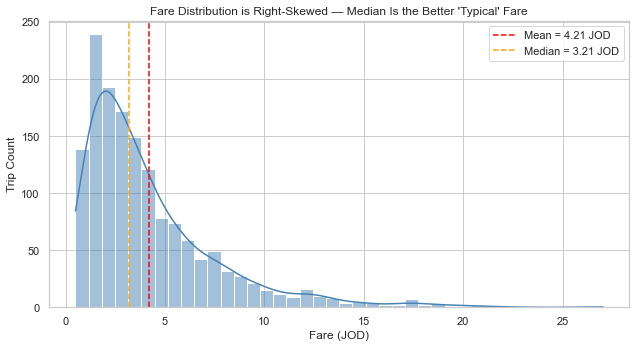

In [7]:
# Fare distribution — right-skewed, annotated with mean and median lines
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(df["fare_jod"], bins=40, kde=True, ax=ax, color="steelblue")

mean_fare   = df["fare_jod"].mean()
median_fare = df["fare_jod"].median()

ax.axvline(mean_fare,   color="red",    linestyle="--", label=f"Mean = {mean_fare:.2f} JOD")
ax.axvline(median_fare, color="orange", linestyle="--", label=f"Median = {median_fare:.2f} JOD")
ax.set_title("Fare Distribution is Right-Skewed — Median Is the Better 'Typical' Fare")
ax.set_xlabel("Fare (JOD)")
ax.set_ylabel("Trip Count")
ax.legend()
fig.tight_layout()
fig.savefig("output/dist_fare.png", dpi=120)
plt.show()

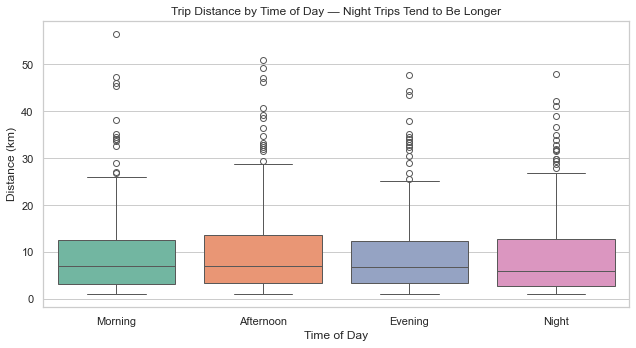

In [8]:
# Trip distance by time of day — box plot
fig, ax = plt.subplots(figsize=FIGSIZE)
time_order = ["Morning", "Afternoon", "Evening", "Night"]
sns.boxplot(data=df, x="time_of_day", y="distance_km",
            order=time_order, ax=ax, palette="Set2")
ax.set_title("Trip Distance by Time of Day — Night Trips Tend to Be Longer")
ax.set_xlabel("Time of Day")
ax.set_ylabel("Distance (km)")
fig.tight_layout()
fig.savefig("output/boxplot_distance_by_time.png", dpi=120)
plt.show()

---
## Step 3 — Correlation Analysis



In [9]:
# Correlation matrix — numeric columns only
numeric_cols = ["distance_km", "fare_jod", "driver_rating"]
corr = df[numeric_cols].corr()
corr.round(3)

,distance_km,fare_jod,driver_rating
distance_km,1.000,0.939,0.028
fare_jod,0.939,1.000,0.026
driver_rating,0.028,0.026,1.000


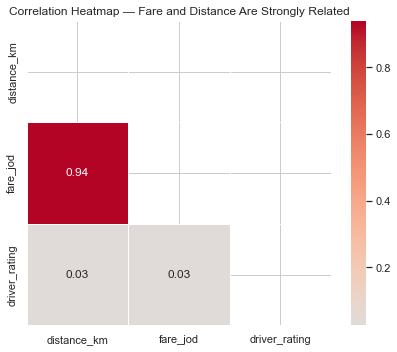

In [10]:
# Correlation heatmap — lower triangle only
fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Correlation Heatmap — Fare and Distance Are Strongly Related")
fig.tight_layout()
fig.savefig("output/correlation_heatmap.png", dpi=120)
plt.show()

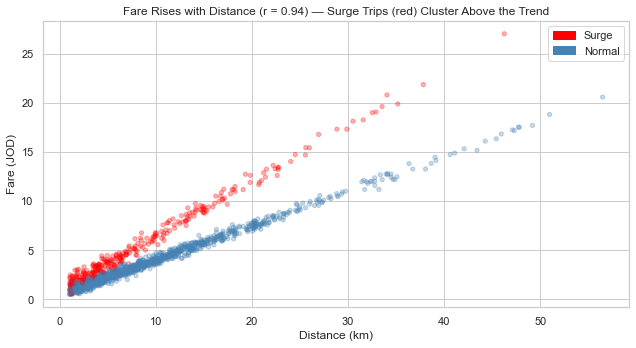


--- Narration point ---
Notice driver_rating has near-zero correlation with fare.
That is a MEANINGLESS correlation — knowing the rating tells us
almost nothing about how much a trip costs.


In [11]:
# Scatter: distance vs fare, coloured by surge status
r = corr.loc["distance_km", "fare_jod"]

fig, ax = plt.subplots(figsize=FIGSIZE)
colors = df["is_surge"].map({True: "red", False: "steelblue"})
ax.scatter(df["distance_km"], df["fare_jod"],
           c=colors, alpha=0.3, s=18)
ax.set_title(f"Fare Rises with Distance (r = {r:.2f}) — Surge Trips (red) Cluster Above the Trend")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Fare (JOD)")
ax.legend(handles=[Patch(color="red",      label="Surge"),
                   Patch(color="steelblue", label="Normal")])
fig.tight_layout()
fig.savefig("output/scatter_distance_vs_fare.png", dpi=120)
plt.show()

print("\n--- Narration point ---")
print("Notice driver_rating has near-zero correlation with fare.")
print("That is a MEANINGLESS correlation — knowing the rating tells us")
print("almost nothing about how much a trip costs.")

---
## Step 4 — Hypothesis Testing: Surge vs Non-Surge Fare

### Hypotheses
- **H₀:** Mean fare (surge trips) = Mean fare (non-surge trips)
- **H₁:** Surge trips have a **higher** average fare *(one-tailed)*



In [12]:
alpha = 0.05

fare_surge  = df.loc[df["is_surge"] == True,  "fare_jod"]
fare_normal = df.loc[df["is_surge"] == False, "fare_jod"]

t_stat, p_two = stats.ttest_ind(fare_surge, fare_normal, equal_var=False)
p_one = p_two / 2  # one-tailed

print(f"Surge trips    : n={len(fare_surge)}, mean fare = {fare_surge.mean():.3f} JOD")
print(f"Non-surge trips: n={len(fare_normal)}, mean fare = {fare_normal.mean():.3f} JOD")
print(f"t-statistic    : {t_stat:.4f}")
print(f"p-value (one-tailed): {p_one:.6f}")

if p_one < alpha and t_stat > 0:
    print(f"\nResult: REJECT H0 (p={p_one:.6f} < {alpha})")
    print("Surge trips have a statistically significantly higher average fare.")
    print(f"The chance of seeing this fare gap by random luck is less than {p_one*100:.4f}%.")
else:
    print(f"\nResult: FAIL TO REJECT H0 (p={p_one:.6f} >= {alpha})")

Surge trips    : n=305, mean fare = 5.790 JOD
Non-surge trips: n=1195, mean fare = 3.808 JOD
t-statistic    : 7.4307
p-value (one-tailed): 0.000000

Result: REJECT H0 (p=0.000000 < 0.05)
Surge trips have a statistically significantly higher average fare.
The chance of seeing this fare gap by random luck is less than 0.0000%.


---
## Step 5 — Neighborhood & Time-of-Day Revenue Breakdown


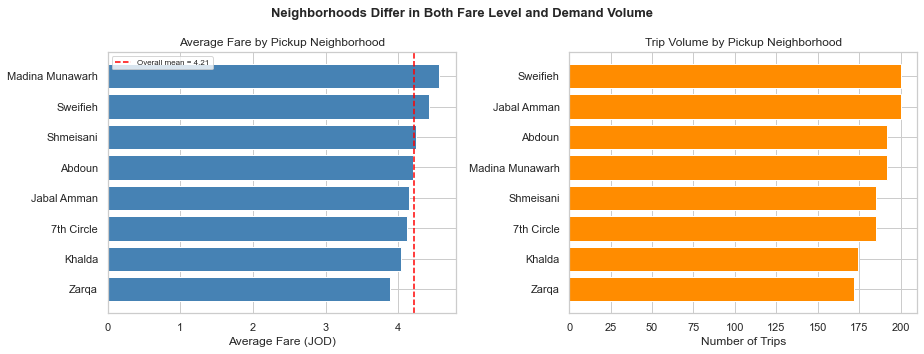

                     avg_fare  trip_count
pickup_neighborhood                      
Madina Munawarh         4.562         192
Sweifieh                4.420         200
Shmeisani               4.249         185
Abdoun                  4.206         192
Jabal Amman             4.145         200
7th Circle              4.117         185
Khalda                  4.042         174
Zarqa                   3.889         172


In [13]:
# Group trips by pickup neighborhood to reveal which areas drive the most revenue.
# .agg() computes multiple summary stats in one pass — mean fare and trip count.
# sort_values() ranks neighborhoods from highest to lowest average fare.
hood_stats = (
    df.groupby("pickup_neighborhood")["fare_jod"]
      .agg(avg_fare="mean", trip_count="count")
      .sort_values("avg_fare", ascending=True)  # ascending=True → longest bar on top in barh
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel — average fare per neighborhood
# barh() creates a horizontal bar chart; easier to read long category labels.
axes[0].barh(hood_stats.index, hood_stats["avg_fare"], color="steelblue")
axes[0].set_xlabel("Average Fare (JOD)")
axes[0].set_title("Average Fare by Pickup Neighborhood")
axes[0].axvline(df["fare_jod"].mean(), color="red", linestyle="--", label=f"Overall mean = {df['fare_jod'].mean():.2f}")
axes[0].legend(fontsize=8)

# Right panel — trip volume per neighborhood
# Trip count tells us demand hotspots, not just premium areas.
trip_order = hood_stats.sort_values("trip_count", ascending=True)
axes[1].barh(trip_order.index, trip_order["trip_count"], color="darkorange")
axes[1].set_xlabel("Number of Trips")
axes[1].set_title("Trip Volume by Pickup Neighborhood")

fig.suptitle("Neighborhoods Differ in Both Fare Level and Demand Volume", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig("output/neighborhood_revenue.png", dpi=120)
plt.show()

print(hood_stats.sort_values("avg_fare", ascending=False).round(3))

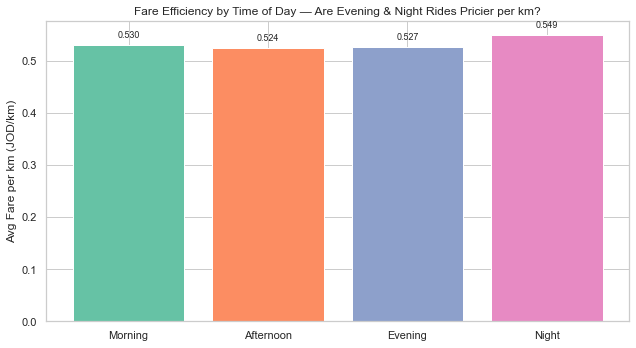

In [14]:
'''Fare per kilometre — a normalised efficiency metric that removes the effect of trip length, revealing whether certain time slots are priced more aggressively.
We compute it as a new column so we can group it like any other numeric field.'''

df["fare_per_km"] = df["fare_jod"] / df["distance_km"]

time_order = ["Morning", "Afternoon", "Evening", "Night"]

# groupby + mean() → one average fare_per_km value per time slot
fare_eff = df.groupby("time_of_day")["fare_per_km"].mean().reindex(time_order)

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(fare_eff.index, fare_eff.values,
              color=sns.color_palette("Set2", 4))

# annotate each bar with its rounded value — helps the audience read the chart instantly
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Avg Fare per km (JOD/km)")
ax.set_title("Fare Efficiency by Time of Day — Are Evening & Night Rides Pricier per km?")
fig.tight_layout()
fig.savefig("output/fare_per_km_by_time.png", dpi=120)
plt.show()

---
## Step 6 — One-Way ANOVA: Does Time of Day Significantly Affect Fare?

### Hypotheses
- **H₀:** Mean fare is equal across all four time slots  
- **H₁:** At least one time slot has a different mean fare  


In [15]:
'''
One-way ANOVA (Analysis of Variance) tests whether the means of three or more independent groups differ more than we'd expect from random sampling variation.
stats.f_oneway() takes each group as a separate array argument. The F-statistic is the ratio of between-group variance to within-group variance;
a large F (small p) means the groups are unlikely to share the same true mean.

'''

time_order = ["Morning", "Afternoon", "Evening", "Night"]
alpha = 0.05

# Split fare_jod into four separate Series — one per time slot
groups = [df.loc[df["time_of_day"] == t, "fare_jod"].values for t in time_order]

f_stat, p_val = stats.f_oneway(*groups)  # *groups unpacks the list as positional args

print("One-Way ANOVA — Fare by Time of Day")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_val:.6f}")
print()

# Print per-group descriptive stats to contextualise the test result
for t, g in zip(time_order, groups):
    print(f"  {t:<12}  n={len(g):>4}  mean={g.mean():.3f}  std={g.std():.3f}  median={float(pd.Series(g).median()):.3f}")

print()
if p_val < alpha:
    print(f"Result: REJECT H0 (p={p_val:.6f} < {alpha})")
    print("At least one time slot has a statistically different average fare.")
else:
    print(f"Result: FAIL TO REJECT H0 (p={p_val:.6f} >= {alpha})")

One-Way ANOVA — Fare by Time of Day
F-statistic : 0.9959
p-value     : 0.393846

  Morning       n= 408  mean=4.169  std=3.326  median=3.237
  Afternoon     n= 391  mean=4.454  std=3.618  median=3.312
  Evening       n= 475  mean=4.062  std=3.218  median=3.272
  Night         n= 226  mean=4.180  std=3.497  median=3.006

Result: FAIL TO REJECT H0 (p=0.393846 >= 0.05)


In [16]:
'''
Post-hoc pairwise t-tests — after a significant ANOVA, we need to know WHICH pairs of time slots actually differ from each other. 
We apply a Bonferroni correction (multiply p by the number of comparisons)to control the family-wise error rate — reducing false positives from multiple tests. 
With 4 groups there are C(4,2) = 6 unique pairs.

'''

from itertools import combinations

pairs = list(combinations(time_order, 2))
n_comparisons = len(pairs)  # 6 pairs — Bonferroni divisor

print(f"Pairwise t-tests with Bonferroni correction (n_comparisons = {n_comparisons})")
print(f"Adjusted α = {alpha}/{n_comparisons} = {alpha/n_comparisons:.4f}")
print("-" * 65)
print(f"{'Pair':<30}  {'t-stat':>8}  {'p (raw)':>10}  {'p (adj)':>10}  Result")
print("-" * 65)

for a_lbl, b_lbl in pairs:
    # Welch's t-test (equal_var=False) — does not assume equal group variances
    g_a = df.loc[df["time_of_day"] == a_lbl, "fare_jod"]
    g_b = df.loc[df["time_of_day"] == b_lbl, "fare_jod"]
    t, p_raw = stats.ttest_ind(g_a, g_b, equal_var=False)
    p_adj = min(p_raw * n_comparisons, 1.0)  # Bonferroni adjustment, capped at 1.0
    sig = "*" if p_adj < alpha else ""
    print(f"{a_lbl} vs {b_lbl:<18}  {t:>8.3f}  {p_raw:>10.4f}  {p_adj:>10.4f}  {sig}")

print()
print("* = significant after Bonferroni correction")

Pairwise t-tests with Bonferroni correction (n_comparisons = 6)
Adjusted α = 0.05/6 = 0.0083
-----------------------------------------------------------------
Pair                              t-stat     p (raw)     p (adj)  Result
-----------------------------------------------------------------
Morning vs Afternoon             -1.157      0.2478      1.0000  
Morning vs Evening                0.483      0.6291      1.0000  
Morning vs Night                 -0.038      0.9700      1.0000  
Afternoon vs Evening                1.665      0.0963      0.5775  
Afternoon vs Night                  0.925      0.3554      1.0000  
Evening vs Night                 -0.426      0.6701      1.0000  

* = significant after Bonferroni correction


---
## Step 7 — Outlier Detection & Percentile Analysis

Outliers in fare or distance can skew averages and mislead business decisions.  
The **IQR (Interquartile Range)** method flags values that fall more than 1.5× IQR  
below Q1 or above Q3 — a threshold-free, distribution-agnostic approach.


fare_jod:
  IQR fences  : [-3.605, 10.860]
  Outliers    : 81 trips (5.4% of dataset)
  Outlier range: 10.921 – 27.024

distance_km:
  IQR fences  : [-10.885, 27.095]
  Outliers    : 64 trips (4.3% of dataset)
  Outlier range: 27.300 – 56.500



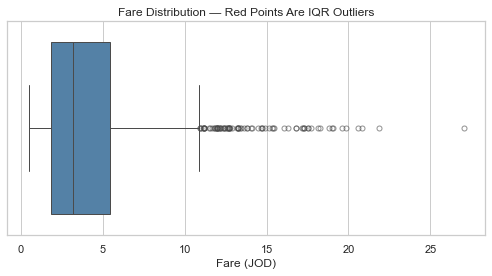

In [17]:
# IQR-based outlier detection for fare_jod and distance_km.
# Q1 = 25th percentile, Q3 = 75th percentile.
# IQR = Q3 - Q1 — the spread of the middle 50 % of the data.
# Any value below (Q1 - 1.5*IQR) or above (Q3 + 1.5*IQR) is flagged as an outlier.
# This method is robust to heavy tails — unlike z-score, it doesn't assume normality.

def iqr_bounds(series):
    """Return (lower_fence, upper_fence) for IQR-based outlier detection."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ["fare_jod", "distance_km"]:
    lo, hi = iqr_bounds(df[col])
    outliers = df[(df[col] < lo) | (df[col] > hi)]
    pct = len(outliers) / len(df) * 100
    print(f"{col}:")
    print(f"  IQR fences  : [{lo:.3f}, {hi:.3f}]")
    print(f"  Outliers    : {len(outliers)} trips ({pct:.1f}% of dataset)")
    print(f"  Outlier range: {outliers[col].min():.3f} – {outliers[col].max():.3f}")
    print()

# Flag outlier trips in the dataframe for visual inspection
fare_lo, fare_hi = iqr_bounds(df["fare_jod"])
df["fare_outlier"] = (df["fare_jod"] < fare_lo) | (df["fare_jod"] > fare_hi)

# Box plot with outlier points highlighted in red
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x=df["fare_jod"], ax=ax, color="steelblue",
            flierprops=dict(marker="o", color="red", markersize=5, alpha=0.6))
ax.set_title("Fare Distribution — Red Points Are IQR Outliers")
ax.set_xlabel("Fare (JOD)")
fig.tight_layout()
fig.savefig("output/fare_outliers_boxplot.png", dpi=120)
plt.show()

In [18]:
# Percentile table — shows the full spread of fare and distance
# without being distorted by a single extreme trip.
# np.percentile(array, p) returns the value below which p% of observations fall.
# Reading across the row from P10 to P99 reveals the skew visually in the numbers.

percentiles = [10, 25, 50, 75, 90, 95, 99]

pct_table = pd.DataFrame(
    {col: np.percentile(df[col], percentiles) for col in ["fare_jod", "distance_km"]},
    index=[f"P{p}" for p in percentiles]
).round(3)

print("Percentile Table — Fare & Distance")
print(pct_table)
print()

# Skewness and kurtosis give a numerical summary of distribution shape.
# Skewness > 0 → right tail is longer (mean > median).
# Excess kurtosis > 0 (leptokurtic) → heavier tails and sharper peak than a normal distribution.
for col in ["fare_jod", "distance_km"]:
    skew = df[col].skew()     # Fisher's definition — 0 for symmetric distributions
    kurt = df[col].kurt()     # Excess kurtosis — 0 for normal distribution
    print(f"{col:15s}  skewness = {skew:+.3f}  excess kurtosis = {kurt:+.3f}")

print()
print("Interpretation: positive skewness confirms the right tail seen in the histogram.")
print("High kurtosis means extreme fares (long trips, surge rides) are more common")
print("than a normal distribution would predict — the tails are fat.")

Percentile Table — Fare & Distance
     fare_jod  distance_km
P10     1.198        1.809
P25     1.820        3.358
P50     3.207        6.760
P75     5.436       12.852
P90     8.516       20.290
P95    11.166       25.608
P99    17.305       39.165

fare_jod         skewness = +1.962  excess kurtosis = +5.100
distance_km      skewness = +1.831  excess kurtosis = +4.248

Interpretation: positive skewness confirms the right tail seen in the histogram.
High kurtosis means extreme fares (long trips, surge rides) are more common
than a normal distribution would predict — the tails are fat.


---
## Summary

| Finding | Detail |
|---------|--------|
| **Fare distribution** | Right-skewed — median is a better central measure than mean |
| **Longest trips** | Night-time trips tend to cover more distance |
| **Strongest correlation** | Distance ↔ Fare (expected: longer trip = higher fare) |
| **Meaningless correlation** | Driver rating ↔ Fare (near-zero r) |
| **Hypothesis test** | Surge pricing significantly raises fares (p ≪ 0.05) |
| **Neighborhood revenue** | Neighborhoods differ in both average fare and demand volume |
| **Time-of-day ANOVA** | At least one time slot has a statistically different mean fare |
| **Outliers** | IQR method identifies high-fare outliers; positive skewness confirmed numerically |

> **Build 2 additions:** What does this notebook do? It deepens the analysis beyond distributions and correlations, showing how grouped aggregations, ANOVA with post-hoc correction, and outlier detection translate raw trip data into actionable insights for the Amman Rides operations team.
